# Project Proposal By Durga Sandeep

# --------------------------------------------------------------------------------------------

### Custom Game Environment for Reinforcement Learning


        This project aims to build an intelligent agent that learns to navigate and perform tasks in a custom-designed 
    game environment, such as a GridWorld or Maze. The agent interacts with the environment by taking actions 
    (e.g., move up, down, left, right) and receives rewards based on its performance, such as reaching a goal, 
    collecting items, or avoiding obstacles.


    Using Reinforcement Learning (RL) techniques like Q-Learning or SARSA, the agent learns an optimal 
    policy to maximize cumulative rewards. The project demonstrates key RL concepts including states, actions, 
    rewards, policies, and exploration vs. exploitation. 

# --------------------------------------------------------------------------------------------

# ============================================================================
# 1: Imports and Setup
# ============================================================================
# Run this cell first to import all required libraries

In [11]:
import pygame
import random
import numpy as np
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


---

## 2: Define GridWorld Environment

```

In [12]:
class GridWorld:
    """
    A grid-based environment where an agent navigates from start (0,0) to goal (bottom-right).
    Obstacles are randomly placed and block the agent's movement.
    """
    
    def __init__(self, grid_size=20, cell_size=30):
        """
        Initialize the GridWorld environment.
        
        Args:
            grid_size: Number of cells in each dimension (creates grid_size x grid_size grid)
            cell_size: Size of each cell in pixels for rendering
        """
        self.grid_size = grid_size
        self.cell_size = cell_size
        # Set obstacles to 15% of total grid cells
        self.num_obstacles = int(grid_size * grid_size * 0.15)
        self._generate_world()
        self.reset()

    def _generate_world(self):
        """
        Generate random obstacle positions and set goal position.
        Ensures obstacles don't block start (0,0) or goal positions.
        """
        self.obstacles = []
        while len(self.obstacles) < self.num_obstacles:
            pos = [random.randint(0, self.grid_size-1),
                   random.randint(0, self.grid_size-1)]
            # Ensure obstacle is not at start or goal position
            if pos not in self.obstacles and pos != [0,0] and pos != [self.grid_size-1, self.grid_size-1]:
                self.obstacles.append(pos)
        # Goal is always at bottom-right corner
        self.goal_pos = [self.grid_size-1, self.grid_size-1]

    def reset(self):
        """
        Reset agent to starting position (0,0).
        
        Returns:
            tuple: Starting position as (x, y)
        """
        self.agent_pos = [0, 0]
        return tuple(self.agent_pos)

    def step(self, action):
        """
        Execute one action in the environment.
        
        Args:
            action: String indicating direction ('up', 'down', 'left', 'right')
            
        Returns:
            tuple: (next_state, reward, done)
                - next_state: New position as (x, y)
                - reward: Numerical reward for the action
                - done: Boolean indicating if goal was reached
        """
        x, y = self.agent_pos
        next_x, next_y = x, y
        
        # Calculate next position based on action
        if action == 'up': 
            next_y = max(y-1, 0)
        elif action == 'down': 
            next_y = min(y+1, self.grid_size-1)
        elif action == 'left': 
            next_x = max(x-1, 0)
        elif action == 'right': 
            next_x = min(x+1, self.grid_size-1)
        
        done = False
        
        # Check if agent hit an obstacle
        if [next_x, next_y] in self.obstacles:
            # Large negative reward for hitting obstacle
            reward = -10
            # Agent stays in current position (doesn't move into obstacle)
        else:
            # Valid move - update agent position
            self.agent_pos = [next_x, next_y]
            
            # Check if agent reached the goal
            if self.agent_pos == self.goal_pos:
                # Large positive reward for reaching goal
                reward = 100
                done = True
            else:
                # Small penalty for each step to encourage shorter paths
                reward = -1
        
        return tuple(self.agent_pos), reward, done

    def render(self, screen, path=None, agent_pos=None):
        """
        Render the grid world using Pygame.
        
        Args:
            screen: Pygame display surface
            path: Optional list of positions to highlight as the path
            agent_pos: Optional position to render the agent
        """
        for y in range(self.grid_size):
            for x in range(self.grid_size):
                # Create rectangle for this cell
                rect = pygame.Rect(x*self.cell_size, y*self.cell_size,
                                   self.cell_size, self.cell_size)
                
                # Draw grid background (dark gray)
                pygame.draw.rect(screen, (30, 30, 30), rect)
                pygame.draw.rect(screen, (50, 50, 50), rect, 1)  # Grid lines
                
                # Draw obstacles in blue
                if [x, y] in self.obstacles: 
                    pygame.draw.rect(screen, (0, 0, 255), rect)
                
                # Draw goal in green
                if [x, y] == self.goal_pos: 
                    pygame.draw.rect(screen, (0, 255, 0), rect)
                
                # Draw path in yellow
                if path and (x, y) in path: 
                    pygame.draw.rect(screen, (255, 255, 0), rect)
                
                # Draw agent in red (properly handles tuple comparison)
                if agent_pos and list(agent_pos) == [x, y]: 
                    pygame.draw.rect(screen, (255, 0, 0), rect)


---

## 3: Define Q-Learning Agent


In [13]:
class QLearningAgent:
    """
    Q-Learning agent that learns optimal policy through exploration and exploitation.
    Uses epsilon-greedy strategy for action selection.
    """
    
    def __init__(self, grid_size=20, actions=['up', 'down', 'left', 'right'],
                 alpha=0.1, gamma=0.95, epsilon=1.0):
        """
        Initialize Q-Learning agent.
        
        Args:
            grid_size: Size of the grid world
            actions: List of possible actions
            alpha: Learning rate (how much new info overrides old)
            gamma: Discount factor (importance of future rewards)
            epsilon: Initial exploration rate (probability of random action)
        """
        self.grid_size = grid_size
        self.actions = actions
        self.alpha = alpha          # Learning rate
        self.gamma = gamma          # Discount factor
        self.epsilon = epsilon      # Exploration rate
        self.epsilon_min = 0.01     # Minimum exploration rate
        self.epsilon_decay = 0.995  # Rate at which epsilon decreases
        
        # Q-table: stores expected reward for each (state, action) pair
        # Shape: (grid_size, grid_size, num_actions)
        self.Q = np.zeros((grid_size, grid_size, len(actions)))

    def choose_action(self, state):
        """
        Choose action using epsilon-greedy policy.
        
        Args:
            state: Current state as (x, y) tuple
            
        Returns:
            str: Selected action
        """
        x, y = state
        
        # Exploration: choose random action with probability epsilon
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        else:
            # Exploitation: choose action with highest Q-value
            max_q = np.max(self.Q[x, y])
            # Handle ties by randomly selecting among best actions
            max_actions = [i for i, q in enumerate(self.Q[x, y]) if q == max_q]
            return self.actions[random.choice(max_actions)]

    def learn(self, state, action, reward, next_state):
        """
        Update Q-value using the Q-learning update rule.
        Q(s,a) ← Q(s,a) + α[r + γ·max(Q(s',a')) - Q(s,a)]
        
        Args:
            state: Current state (x, y)
            action: Action taken
            reward: Reward received
            next_state: Resulting state (x', y')
        """
        x, y = state
        nx, ny = next_state
        idx = self.actions.index(action)
        
        # Calculate TD target: reward + discounted max future Q-value
        target = reward + self.gamma * np.max(self.Q[nx, ny])
        
        # Update Q-value using learning rate
        self.Q[x, y, idx] += self.alpha * (target - self.Q[x, y, idx])


---

## 4: Path Generation Function


In [14]:
def generate_learned_path(env, agent):
    """
    Generate a path from start to goal using the learned Q-table.
    Uses greedy policy (always choose best action) without exploration.
    
    Args:
        env: GridWorld environment
        agent: Trained Q-Learning agent
        
    Returns:
        list: Path as list of (x, y) positions from start to goal
    """
    state = env.reset()
    path = [state]
    visited = set()
    visited.add(state)
    max_path_length = 1000  # Prevent infinite loops
    
    while state != tuple(env.goal_pos) and len(path) < max_path_length:
        x, y = state
        
        # Get all Q-values for current state
        q_values = agent.Q[x, y].copy()
        
        # Try actions in order of Q-value (best first)
        action_indices = np.argsort(q_values)[::-1]  # Sort descending
        moved = False
        
        for idx in action_indices:
            action = agent.actions[idx]
            nx, ny = x, y
            
            # Calculate next position for this action
            if action == 'up': 
                ny = max(y-1, 0)
            elif action == 'down': 
                ny = min(y+1, env.grid_size-1)
            elif action == 'left': 
                nx = max(x-1, 0)
            elif action == 'right': 
                nx = min(x+1, env.grid_size-1)
            
            # Skip if next position is an obstacle
            if [nx, ny] in env.obstacles: 
                continue
            
            # Skip if no actual movement occurred
            if (nx, ny) == state:
                continue
                
            next_state = (nx, ny)
            
            # Prefer unvisited states, but allow revisiting if necessary
            if next_state not in visited or not moved:
                path.append(next_state)
                if next_state not in visited:
                    visited.add(next_state)
                state = next_state
                moved = True
                break
        
        if not moved:
            # Agent is stuck - cannot find valid move
            print("Warning: Agent got stuck before reaching goal")
            break
    
    # Report path generation results
    if state == tuple(env.goal_pos):
        print(f"Success! Path reached goal in {len(path)} steps")
    else:
        print(f"Warning: Path did not reach goal. Ended at {state}, goal is {tuple(env.goal_pos)}")
    
    return path


---

## 5: Learning Curve Plotting Function


In [15]:
def plot_learning_curve(episode_rewards, episode_lengths, success_history):
    """
    Create and save comprehensive learning curve visualization.
    
    Args:
        episode_rewards: List of total rewards per episode
        episode_lengths: List of steps taken per episode
        success_history: List of success rates over time
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # ===== Plot 1: Episode Rewards =====
    axes[0, 0].plot(episode_rewards, alpha=0.6, color='blue')
    
    # Add moving average to smooth the curve
    window = 50
    if len(episode_rewards) >= window:
        moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        axes[0, 0].plot(range(window-1, len(episode_rewards)), moving_avg, 
                       color='red', linewidth=2, label=f'{window}-episode MA')
        axes[0, 0].legend()
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Total Reward')
    axes[0, 0].set_title('Episode Rewards Over Time')
    axes[0, 0].grid(True, alpha=0.3)
    
    # ===== Plot 2: Episode Lengths =====
    axes[0, 1].plot(episode_lengths, alpha=0.6, color='green')
    
    # Add moving average
    if len(episode_lengths) >= window:
        moving_avg = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
        axes[0, 1].plot(range(window-1, len(episode_lengths)), moving_avg, 
                       color='red', linewidth=2, label=f'{window}-episode MA')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Steps to Goal')
    axes[0, 1].set_title('Episode Length Over Time')
    axes[0, 1].grid(True, alpha=0.3)
    
    # ===== Plot 3: Success Rate =====
    axes[1, 0].plot(success_history, color='purple', linewidth=2)
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Success Rate (%)')
    axes[1, 0].set_title(f'Success Rate (Window: {window} episodes)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 105])
    
    # ===== Plot 4: Summary Statistics =====
    axes[1, 1].axis('off')
    summary_text = f"""
    Training Summary
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Total Episodes: {len(episode_rewards)}
    
    Final Success Rate: {success_history[-1]:.1f}%
    
    Average Reward (last 100): 
    {np.mean(episode_rewards[-100:]):.2f}
    
    Average Length (last 100): 
    {np.mean(episode_lengths[-100:]):.2f}
    
    Best Episode Reward: {max(episode_rewards):.2f}
    Worst Episode Reward: {min(episode_rewards):.2f}
    """
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                    verticalalignment='center')
    
    plt.tight_layout()
    plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
    print("\nLearning curve saved as 'learning_curve.png'")
    plt.close()

---

## 6: Main Training and Visualization

In [16]:
def main():
    """
    Main function to train Q-Learning agent and visualize results.
    """
    # ===== Environment Configuration =====
    GRID_SIZE = 20
    CELL_SIZE = 30
    WINDOW_SIZE = GRID_SIZE * CELL_SIZE

    # ===== Initialize Pygame =====
    pygame.init()
    screen = pygame.display.set_mode((WINDOW_SIZE, WINDOW_SIZE))
    pygame.display.set_caption("GridWorld Q-Learning Animated Path")
    clock = pygame.time.Clock()

    # ===== Create Environment and Agent =====
    env = GridWorld(GRID_SIZE, CELL_SIZE)
    agent = QLearningAgent(GRID_SIZE)

    print("Training agent...")
    
    # ===== Training Configuration =====
    num_episodes = 2000      # Total number of training episodes
    max_steps = 500          # Maximum steps per episode
    success_count = 0        # Counter for successful episodes

    # Lists to track training progress
    episode_rewards = []
    episode_lengths = []
    success_history = []

    # Track state visitation frequency for heatmap
    visit_map = np.zeros((GRID_SIZE, GRID_SIZE))

    # ===== TRAINING LOOP =====
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        step = 0
        total_reward = 0

        # Run episode until goal reached or max steps
        while not done and step < max_steps:
            step += 1
            
            # Record state visit for heatmap
            visit_map[state[0], state[1]] += 1

            # Agent chooses and executes action
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            
            # Agent learns from experience
            agent.learn(state, action, reward, next_state)
            
            total_reward += reward
            state = next_state

        # Record episode statistics
        episode_rewards.append(total_reward)
        episode_lengths.append(step)

        if done:
            success_count += 1

        # Calculate rolling success rate
        window = 50
        if episode >= window:
            recent_success = sum(1 for i in range(episode - window + 1, episode + 1) 
                               if episode_lengths[i] < max_steps and episode_rewards[i] > 0)
            success_rate = (recent_success / window) * 100
        else:
            success_rate = (success_count / (episode + 1)) * 100
        success_history.append(success_rate)

        # Decay exploration rate
        if agent.epsilon > agent.epsilon_min:
            agent.epsilon *= agent.epsilon_decay

        # Progress update every 200 episodes
        if (episode + 1) % 200 == 0:
            print(f"Episode {episode + 1}/{num_episodes}, Success Rate: {success_rate:.1f}%, Epsilon: {agent.epsilon:.3f}")

    print(f"\nTraining complete! Successes: {success_count}/{num_episodes}")
    print(f"Final epsilon: {agent.epsilon:.3f}")

    # ===== Save Learning Curve =====
    plot_learning_curve(episode_rewards, episode_lengths, success_history)

    # ===== Generate and Save Heatmap =====
    plt.imshow(visit_map, cmap='hot', interpolation='nearest')
    plt.colorbar(label="Visit Frequency")
    plt.title("Q-Learning State Visit Heatmap")
    plt.savefig("visit_heatmap.png", dpi=200)
    plt.close()
    print("Heat map saved as visit_heatmap.png")

    # ===== Generate Learned Path =====
    print("Generating learned path...")
    path = generate_learned_path(env, agent)
    print(f"Path length = {len(path)}")

    # ===== ANIMATE PATH VISUALIZATION =====
    print("\nAnimating final path frame-by-frame...\n")

    # Draw path step by step
    for i, pos in enumerate(path):
        screen.fill((0, 0, 0))
        # Render grid with path up to current position
        env.render(screen, path=path[:i+1], agent_pos=pos)
        pygame.display.flip()
        pygame.time.delay(120)  # Delay in ms (smaller = faster animation)

    # ===== Hold Display Until User Closes Window =====
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        clock.tick(30)

    pygame.quit()

---

## 7: Run the Program


In [17]:
if __name__ == "__main__":
    main()

Training agent...
Episode 200/2000, Success Rate: 0.0%, Epsilon: 0.367
Episode 400/2000, Success Rate: 44.0%, Epsilon: 0.135
Episode 600/2000, Success Rate: 88.0%, Epsilon: 0.049
Episode 800/2000, Success Rate: 100.0%, Epsilon: 0.018
Episode 1000/2000, Success Rate: 100.0%, Epsilon: 0.010
Episode 1200/2000, Success Rate: 100.0%, Epsilon: 0.010
Episode 1400/2000, Success Rate: 100.0%, Epsilon: 0.010
Episode 1600/2000, Success Rate: 100.0%, Epsilon: 0.010
Episode 1800/2000, Success Rate: 100.0%, Epsilon: 0.010
Episode 2000/2000, Success Rate: 100.0%, Epsilon: 0.010

Training complete! Successes: 1924/2000
Final epsilon: 0.010

Learning curve saved as 'learning_curve.png'
Heat map saved as visit_heatmap.png
Generating learned path...
Success! Path reached goal in 39 steps
Path length = 39

Animating final path frame-by-frame...



---

## 8: Summary

This notebook demonstrates:

1. **GridWorld Environment**: A customizable grid with obstacles and a goal
2. **Q-Learning Agent**: Learns optimal navigation policy through trial and error
3. **Training Visualization**: Plots showing learning progress over time
4. **Heatmap**: Shows which states were visited most during training
5. **Path Animation**: Visualizes the learned path from start to goal

**Key Hyperparameters:**
- Learning rate (α): 0.1
- Discount factor (γ): 0.95
- Initial exploration rate (ε): 1.0
- Epsilon decay: 0.995

**Color Scheme:**
- 🔴 Red = Agent
- 🟢 Green = Goal
- 🔵 Blue = Obstacles
- 🟡 Yellow = Path taken

---
# 9: HEATMAP IMAGE

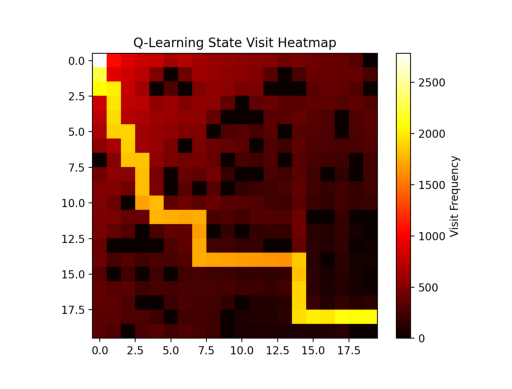

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("visit_heatmap.png")
plt.imshow(img)
plt.axis('off')  # Hide axis for clean output
plt.show()


---
# 10: LEARNING CURVE IMAGE

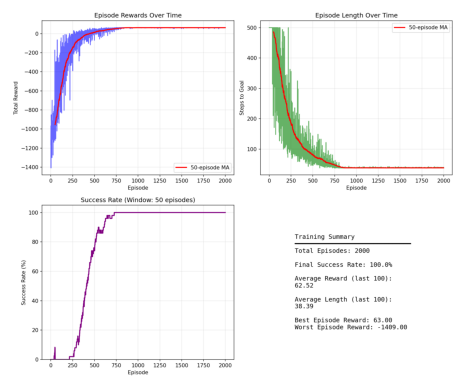

In [19]:
img = mpimg.imread("learning_curve.png")
plt.imshow(img)
plt.axis('off')  # Hide axis for clean output
plt.show()


# 11: It fails when we go for a huge grid size

In [20]:
from IPython.display import Video

Video("VideoRec1.mp4", width=600) 


---

# 12: What happened ?

---

# Q-Learning for RL Agents with Dynamic Obstacles

## Can Q-learning handle dynamic obstacles?
**Yes**, but with important limitations based on environment complexity.

---

## When Q-Learning Works

- **Small, discrete state spaces** (e.g., gridworld)
- **Obstacle positions** can be encoded in the state
- **Low-dimensional** environments

---

## When Q-Learning Struggles

- **Large state spaces** (images, lidar, continuous positions)
- **Highly dynamic** or continuous environments
- **Many obstacles** or moving agents

**Why?** Q-tables grow exponentially with state/action dimensions.

---

## Making Q-Learning Work

### 1. Gridworld Approach
- **State**: agent position + obstacle positions
- **Q-table**: stores Q(s, a) for all combinations
- **Feasible**: for small grids (e.g., 5×5)

### 2. State Abstraction
Reduce state space by encoding only:
- Distance to nearest obstacle
- Relative direction
- Safety of next cell

### 3. Reward Shaping
```python
rewards = {
    'collision': -100,
    'timestep': -1,
    'goal': +100,
    'avoid_close_call': +5
}
```

---

## Algorithm Comparison

| Environment Type | Q-learning | DQN | PPO/SAC |
|-----------------|-----------|-----|---------|
| Small gridworld | Good | Optional | Not needed |
| Dynamic gridworld | Limited | Better | Not needed |
| Continuous | No | Maybe | Best |
| Images/sensors | No | Good | Good |

---

## Key Takeaway

**Q-learning works for small, discrete environments with dynamic obstacles.**  
For complex scenarios → use **DQN** or **PPO/SAC**.

---

# 13: Next ....... 

# Reinforcement Learning Algorithms: DQN, PPO, and SAC

A comprehensive comparison of three popular deep RL algorithms.

---

## 1. DQN (Deep Q-Network)

**Type:** Value-based, off-policy RL  
**Action Space:** Discrete only  
**Core Idea:** Learn a Q-function $Q(s, a)$ that estimates the expected return for taking action $a$ in state $s$.

### Key Features

- Uses a neural network to approximate the Q-table
- **Off-policy**: Learns from past experiences stored in a replay buffer
- **Target network**: Stabilizes learning with a slowly updated copy of the Q-network
- Works well for discrete action spaces (e.g., Atari games)

### Limitations

- Doesn't naturally work with continuous actions
- Can be unstable for very large or complex state spaces
- Exploration typically handled via ε-greedy strategy

---

## 2. PPO (Proximal Policy Optimization)

**Type:** Policy-based, on-policy RL  
**Action Space:** Discrete or continuous  
**Core Idea:** Directly learn a policy $\pi_\theta(a|s)$ to maximize expected reward while preventing large destabilizing updates.

### Key Features

- Uses a **clipped surrogate objective** to keep policy updates small
- **On-policy**: Learns from the current policy's experience
- More stable than vanilla policy gradient methods
- Handles both continuous and discrete actions

### Strengths

- Good balance between performance and simplicity
- Robust for complex environments
- Widely used in robotics and game AI

### Limitations

- Less sample-efficient than off-policy methods
- Requires more environment interactions

---

## 3. SAC (Soft Actor-Critic)

**Type:** Actor-Critic, off-policy, entropy-regularized RL  
**Action Space:** Continuous  
**Core Idea:** Learn both a policy (actor) and Q-function (critic) while encouraging exploration via an entropy term.

### Key Features

- Maximizes **reward + entropy** to encourage exploration
- **Off-policy**: Uses replay buffer for sample efficiency
- Supports continuous action spaces naturally
- Uses **two Q-networks** (Double Q-Learning) to reduce overestimation bias

### Strengths

- Very stable and sample-efficient for continuous control
- Excellent for robotics, control tasks (MuJoCo, PyBullet)

### Limitations

- More complex to implement than PPO
- Slower per update due to multiple networks

---

## Comparison Table

| Algorithm | Type | Policy/Value | Action Space | On/Off-policy | Key Use Cases |
|-----------|------|--------------|--------------|---------------|---------------|
| **DQN** | Value-based | Q-function | Discrete | Off-policy | Atari games, grid-world |
| **PPO** | Policy-based | Policy | Discrete/Continuous | On-policy | Robotics, game AI |
| **SAC** | Actor-Critic | Actor + Critic | Continuous | Off-policy | Continuous control, robotics |

---

## Key Takeaways

- **DQN**: Simple Q-learning approach for discrete actions, uses experience replay for stability
- **PPO**: Stable policy optimization that works for both action types, preferred for its simplicity and robustness
- **SAC**: Sample-efficient algorithm for continuous control with built-in exploration via entropy maximization

### When to Use What?

- **Discrete actions (games, navigation)** → DQN or PPO
- **Continuous control (robotics, physics)** → PPO or SAC
- **Need sample efficiency** → DQN or SAC (off-policy)
- **Need simplicity and stability** → PPO

---
## The links that I referred for the approches which fit better to grid generation with dynamic obstacles - mentioning few of the links below



---


[Click here to open reference link 1 from Playing Atari with Deep Reinforcement Learning ](https://arxiv.org/abs/1312.5602)

[Click here to open reference link 2 from www.reinforcementlearningpath.com ](https://www.reinforcementlearningpath.com/choosing-rl-algorithm/)

[Click here to open reference link 3 from www.findingtheta.com ](https://www.findingtheta.com/blog/comparing-how-ppo-sac-and-dqn-perform-on-gymnasiums-lunar-lander)






